# Task 3: Universal Sparse Autoencoders (USAE)

This notebook implements a Universal Sparse Autoencoder to align internal representations of two distinct vision models: **ResNet-18** and **ViT-B-16**.

### Improvements in this version:
1. **Activation Normalization:** We compute the mean/std of activations before training. This is crucial for USAEs to prevent one model from dominating the shared latent space due to magnitude differences.
2. **Regularized Visualization:** We add Gaussian smoothing to the Activation Maximization step to generate interpretable feature visualizations instead of high-frequency noise.

In [1]:
# 1. Setup and Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights, vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import r2_score
import random

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
DICT_SIZE = 2048  # Size of shared feature space (m)
TOP_K = 32        # Sparsity constraint
LEARNING_RATE = 3e-4
NUM_EPOCHS = 8    # Increased slightly for better convergence

print(f"Running on {DEVICE}")

Running on cuda


## 2. Data and Models

In [2]:
# Data Loading
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize for standard models
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Using a subset of CIFAR10. 
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset_indices = range(0, 10000) # Increased to 10k for better statistics
train_dataset = Subset(full_dataset, subset_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Validation set
val_dataset = Subset(full_dataset, range(10000, 11000))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Load Models
model_a = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
model_b = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1).to(DEVICE)

model_a.eval()
model_b.eval()

# Feature Extraction Hooks
activations = {}

def get_activation(name):
    def hook(model, input, output):
        if len(output.shape) > 2:
            activations[name] = output.flatten(1)
        else:
             activations[name] = output
    return hook

model_a.avgpool.register_forward_hook(get_activation('resnet'))

def get_vit_activation(name):
    def hook(model, input, output):
        # ViT output: (batch, seq, dim). Index 0 is CLS.
        activations[name] = output[:, 0, :]
    return hook

model_b.encoder.layers[-1].register_forward_hook(get_vit_activation('vit'))

print("Models loaded and hooks attached.")

Models loaded and hooks attached.


In [3]:
# --- PRE-CALCULATE STATISTICS FOR NORMALIZATION ---
# SAEs align much better if inputs have Unit Variance.

def compute_activation_stats(loader, num_batches=20):
    print("Computing activation statistics...")
    res_acts = []
    vit_acts = []
    
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches: break
            images = images.to(DEVICE)
            model_a(images)
            res_acts.append(activations['resnet'].clone())
            model_b(images)
            vit_acts.append(activations['vit'].clone())
            
    res_all = torch.cat(res_acts, dim=0)
    vit_all = torch.cat(vit_acts, dim=0)
    
    stats = {
        'resnet_mean': res_all.mean(0),
        'resnet_std': res_all.std(0) + 1e-6,
        'vit_mean': vit_all.mean(0),
        'vit_std': vit_all.std(0) + 1e-6
    }
    return stats

stats = compute_activation_stats(train_loader)
print("Stats computed.")

Computing activation statistics...
Stats computed.


## 3. Universal Sparse Autoencoder (USAE) Implementation

In [4]:
class UniversalSparseAutoencoder(nn.Module):
    def __init__(self, input_dims, dict_size, k=32):
        super().__init__()
        self.num_models = len(input_dims)
        self.k = k
        self.dict_size = dict_size
        
        # Encoders: Map Model_i -> Shared Z
        self.encoders = nn.ModuleList([
            nn.Linear(dim, dict_size) for dim in input_dims
        ])
        
        # Decoders: Map Shared Z -> Model_i
        self.decoders = nn.ModuleList([
            nn.Linear(dict_size, dim) for dim in input_dims
        ])
        
        # Pre-biases (subtracted before encode)
        self.b_pre = nn.ParameterList([nn.Parameter(torch.zeros(dim)) for dim in input_dims])
        # Decoder biases
        self.b_dec = nn.ParameterList([nn.Parameter(torch.zeros(dim)) for dim in input_dims])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
                
    def forward(self, activations_list, force_source_idx=None):
        # (a) Select Source
        if force_source_idx is not None:
            src_idx = force_source_idx
        else:
            src_idx = random.randint(0, self.num_models - 1)
            
        src_act = activations_list[src_idx]
        
        # (b) Encode: Z = TopK(W_enc(A - b_pre))
        pre_activations = self.encoders[src_idx](src_act - self.b_pre[src_idx])
        
        # TopK Operation
        topk_vals, topk_indices = torch.topk(pre_activations, k=self.k, dim=1)
        
        # Create sparse Z vector
        z = torch.zeros_like(pre_activations)
        z.scatter_(1, topk_indices, topk_vals)
        
        # (c) Universal Decode
        reconstructions = []
        for j in range(self.num_models):
            # A_hat = Z * W_dec + b_dec
            rec = self.decoders[j](z) + self.b_dec[j]
            reconstructions.append(rec)
            
        return reconstructions, z, src_idx

## 4. Training the USAE

Starting Training...


Epoch 8/8: 100%|██████████| 157/157 [02:08<00:00,  1.22it/s, Loss=1.02] 


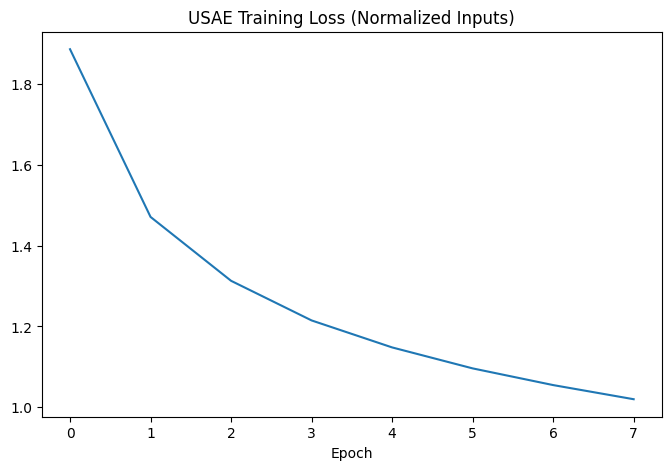

In [5]:
# Initialize USAE
usae = UniversalSparseAutoencoder(input_dims=[512, 768], dict_size=DICT_SIZE, k=TOP_K).to(DEVICE)
optimizer = optim.Adam(usae.parameters(), lr=LEARNING_RATE)

loss_history = []

def get_normalized_batch(images):
    images = images.to(DEVICE)
    with torch.no_grad():
        model_a(images)
        raw_a = activations['resnet'].clone()
        model_b(images)
        raw_b = activations['vit'].clone()
        
    # Normalize
    norm_a = (raw_a - stats['resnet_mean']) / stats['resnet_std']
    norm_b = (raw_b - stats['vit_mean']) / stats['vit_std']
    
    return [norm_a, norm_b]

print("Starting Training...")

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for images, _ in pbar:
        # 1. Get Normalized Activations
        acts = get_normalized_batch(images)
        
        # 2. Forward Pass
        reconstructions, z, src_idx = usae(acts)
        
        # 3. Compute Loss
        loss = 0
        for j in range(len(acts)):
            loss += nn.MSELoss()(reconstructions[j], acts[j])
            
        # 4. Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": loss.item()})
    
    loss_history.append(epoch_loss / len(train_loader))

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("USAE Training Loss (Normalized Inputs)")
plt.xlabel("Epoch")
plt.show()

## 5. Evaluation: R2 Matrix

Evaluating R2: 100%|██████████| 16/16 [00:12<00:00,  1.26it/s]


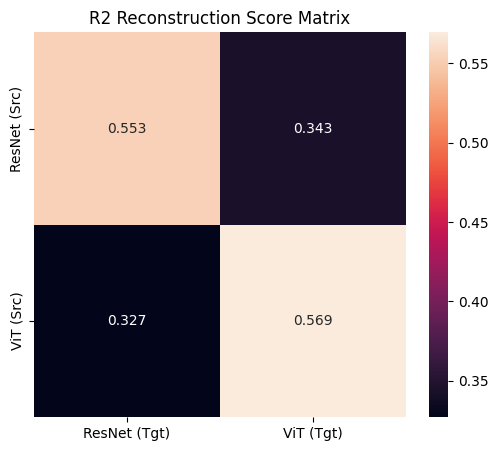

In [6]:
def compute_r2_matrix(model, loader):
    model.eval()
    preds = [[[], []], [[], []]] # [src][tgt]
    targets = [[], []]
    
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Evaluating R2"):
            acts = get_normalized_batch(images)
            
            for j in range(2):
                targets[j].append(acts[j].cpu().numpy())
            
            # Source 0 -> All
            recs_0, _, _ = model(acts, force_source_idx=0)
            preds[0][0].append(recs_0[0].cpu().numpy())
            preds[0][1].append(recs_0[1].cpu().numpy())
            
            # Source 1 -> All
            recs_1, _, _ = model(acts, force_source_idx=1)
            preds[1][0].append(recs_1[0].cpu().numpy())
            preds[1][1].append(recs_1[1].cpu().numpy())
            
    r2_matrix = np.zeros((2, 2))
    for src in range(2):
        for tgt in range(2):
            T = np.concatenate(targets[tgt], axis=0)
            P = np.concatenate(preds[src][tgt], axis=0)
            r2_matrix[src, tgt] = r2_score(T, P)
            
    return r2_matrix

r2_mat = compute_r2_matrix(usae, val_loader)

plt.figure(figsize=(6, 5))
sns.heatmap(r2_mat, annot=True, fmt=".3f", 
            xticklabels=['ResNet (Tgt)', 'ViT (Tgt)'], 
            yticklabels=['ResNet (Src)', 'ViT (Src)'])
plt.title("R2 Reconstruction Score Matrix")
plt.show()

## 6. Quantifying Universality

Analyzing Stats: 100%|██████████| 16/16 [00:11<00:00,  1.42it/s]


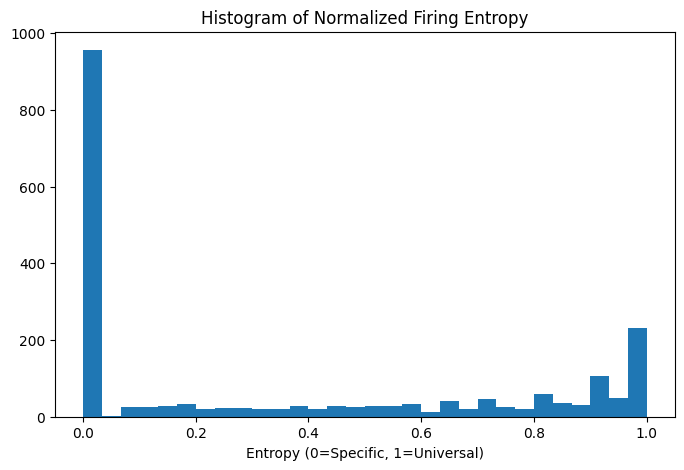

Universal: [ 257 1838  810], Specific: [1283 1284  681]


In [7]:
def analyze_feature_stats(model, loader, dict_size):
    model.eval()
    feature_counts = torch.zeros(dict_size, 2).to(DEVICE)
    co_fire_count = torch.zeros(dict_size).to(DEVICE)
    
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Analyzing Stats"):
            acts = get_normalized_batch(images)
            
            _, z0, _ = model(acts, force_source_idx=0)
            _, z1, _ = model(acts, force_source_idx=1)
            
            active0 = (z0 > 0).float()
            active1 = (z1 > 0).float()
            
            feature_counts[:, 0] += active0.sum(0)
            feature_counts[:, 1] += active1.sum(0)
            
            intersection = (active0 * active1)
            co_fire_count += intersection.sum(0)

    return feature_counts, co_fire_count

feature_counts, co_fire = analyze_feature_stats(usae, val_loader, DICT_SIZE)

# Calculate Entropy
total_fires = feature_counts.sum(1, keepdim=True) + 1e-8
probs = feature_counts / total_fires
probs = torch.clamp(probs, 1e-8, 1.0)
entropy = -torch.sum(probs * torch.log(probs), dim=1) / np.log(2)
entropy = entropy.cpu().numpy()

plt.figure(figsize=(8, 5))
plt.hist(entropy, bins=30, range=(0, 1))
plt.title("Histogram of Normalized Firing Entropy")
plt.xlabel("Entropy (0=Specific, 1=Universal)")
plt.show()

# Identify Indices
active_mask = (total_fires.squeeze() > 20).cpu().numpy() # Must fire at least 20 times
valid_indices = np.where(active_mask)[0]

if len(valid_indices) == 0:
    print("No features fired enough! Check training.")
    universal_indices = [0, 1, 2]
    specific_indices = [0, 1, 2]
else:
    valid_entropy = entropy[valid_indices]
    sorted_indices = np.argsort(valid_entropy)[::-1]
    
    universal_indices = valid_indices[sorted_indices[:3]]
    specific_indices = valid_indices[sorted_indices[-3:]]

print(f"Universal: {universal_indices}, Specific: {specific_indices}")

## 7. Visualization: Coordinated Activation Maximization
Includes regularization (Blur/Decay) to create interpretable images.

Optimizing Feature 257...


Optimizing Feature 1838...


Optimizing Feature 810...


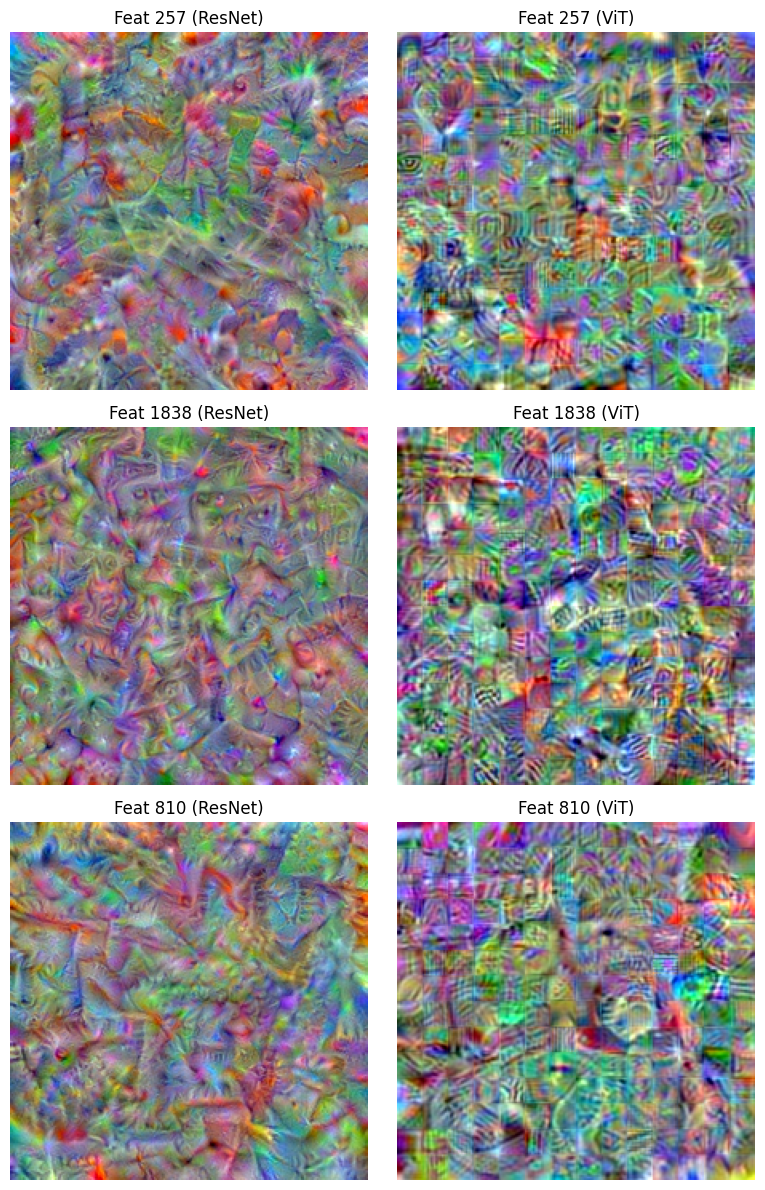

In [14]:
def optimize_feature_robust(model_backbone, model_sae_encoder, model_idx, feature_idx, steps=200):
    # Initialize with grey-ish noise
    img = torch.randn(1, 3, 224, 224, device=DEVICE) * 0.1 + 0.5
    img = img.clamp(0, 1).requires_grad_(True)
    
    # Lower LR, add weight decay
    optimizer = optim.Adam([img], lr=0.05)
    
    # Augmentation for Robustness
    blur = transforms.GaussianBlur(5, sigma=(0.5, 1.0))
    
    for i in range(steps):
        optimizer.zero_grad()
        
        # Forward Backbone
        if model_idx == 0:
            model_backbone(img)
            raw_act = activations['resnet'].flatten(1)
            # Normalize using pre-calc stats
            act = (raw_act - stats['resnet_mean']) / stats['resnet_std']
        else:
            model_backbone(img)
            raw_act = activations['vit']
            act = (raw_act - stats['vit_mean']) / stats['vit_std']
        
        # Encode
        pre_act = model_sae_encoder(act - usae.b_pre[model_idx])
        
        # Maximize feature
        loss = -pre_act[:, feature_idx].sum()
        loss.backward()
        optimizer.step()
        
        # Regularization: Blur every few steps to kill high-freq noise
        if i % 4 == 0:
            with torch.no_grad():
                img.data = blur(img.data)
                img.data = img.data.clamp(0, 1)
                
    return img.detach().cpu().squeeze().permute(1, 2, 0)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
for i, feat_idx in enumerate(universal_indices):
    print(f"Optimizing Feature {feat_idx}...")
    img_res = optimize_feature_robust(model_a, usae.encoders[0], 0, feat_idx)
    img_vit = optimize_feature_robust(model_b, usae.encoders[1], 1, feat_idx)
    
    axes[i, 0].imshow(img_res)
    axes[i, 0].set_title(f"Feat {feat_idx} (ResNet)")
    axes[i, 0].axis('off')
    axes[i, 1].imshow(img_vit)
    axes[i, 1].set_title(f"Feat {feat_idx} (ViT)")
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

## 8. Analysis: Alignment Tax

In [9]:
# Independent SAE for ResNet
print("Training Independent SAE...")
ind_sae = UniversalSparseAutoencoder(input_dims=[512], dict_size=DICT_SIZE, k=TOP_K).to(DEVICE)
ind_opt = optim.Adam(ind_sae.parameters(), lr=LEARNING_RATE)

for epoch in range(5):
    for images, _ in train_loader:
        acts = get_normalized_batch(images)
        # Only pass ResNet act
        rec, _, _ = ind_sae([acts[0]], force_source_idx=0)
        loss = nn.MSELoss()(rec[0], acts[0])
        
        ind_opt.zero_grad()
        loss.backward()
        ind_opt.step()

def evaluate_single_r2(sae_model, loader, dim_idx=0):
    sae_model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for images, _ in loader:
            acts = get_normalized_batch(images)
            targets.append(acts[0].cpu().numpy())
            
            if sae_model.num_models > 1:
                rec, _, _ = sae_model(acts, force_source_idx=0)
                preds.append(rec[0].cpu().numpy())
            else:
                rec, _, _ = sae_model([acts[0]])
                preds.append(rec[0].cpu().numpy())
                
    return r2_score(np.concatenate(targets), np.concatenate(preds))

r2_ind = evaluate_single_r2(ind_sae, val_loader)
r2_usae = evaluate_single_r2(usae, val_loader)
print(f"Independent R2: {r2_ind:.4f} | USAE R2: {r2_usae:.4f} | Tax: {r2_ind - r2_usae:.4f}")

Training Independent SAE...
Independent R2: 0.5917 | USAE R2: 0.5528 | Tax: 0.0390


Average Co-Firing Proportion: 0.1632
(On average, when a feature fires for ResNet, it fires for ViT 16.32% of the time)


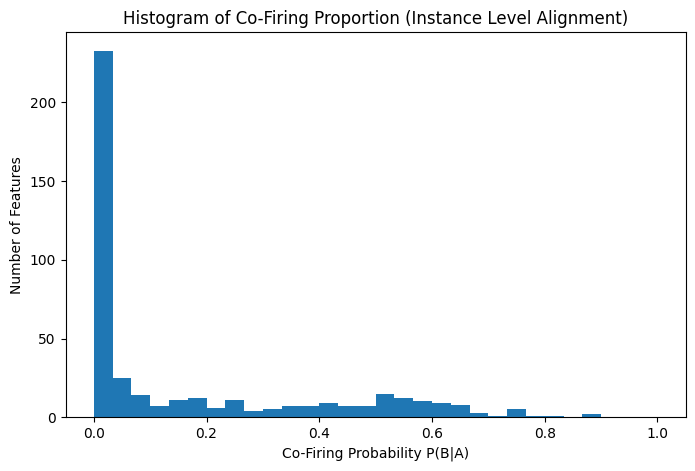

In [10]:
model_a_fire_counts = feature_counts[:, 0]
co_firing_proportion = co_fire / (model_a_fire_counts + 1e-8)

# Filter for features that actually fire (active features) to get meaningful stats
active_mask = model_a_fire_counts > 20 
avg_cofire = co_firing_proportion[active_mask].mean().item()

print(f"Average Co-Firing Proportion: {avg_cofire:.4f}")
print("(On average, when a feature fires for ResNet, it fires for ViT {:.2f}% of the time)".format(avg_cofire*100))

# Plot Histogram
plt.figure(figsize=(8, 5))
plt.hist(co_firing_proportion[active_mask].cpu().numpy(), bins=30, range=(0, 1))
plt.title("Histogram of Co-Firing Proportion (Instance Level Alignment)")
plt.xlabel("Co-Firing Probability P(B|A)")
plt.ylabel("Number of Features")
plt.show()

Visualizing Model-Specific Features: [1283 1284  681]
Optimizing Specific Feature 1283...


Optimizing Specific Feature 1284...


Optimizing Specific Feature 681...


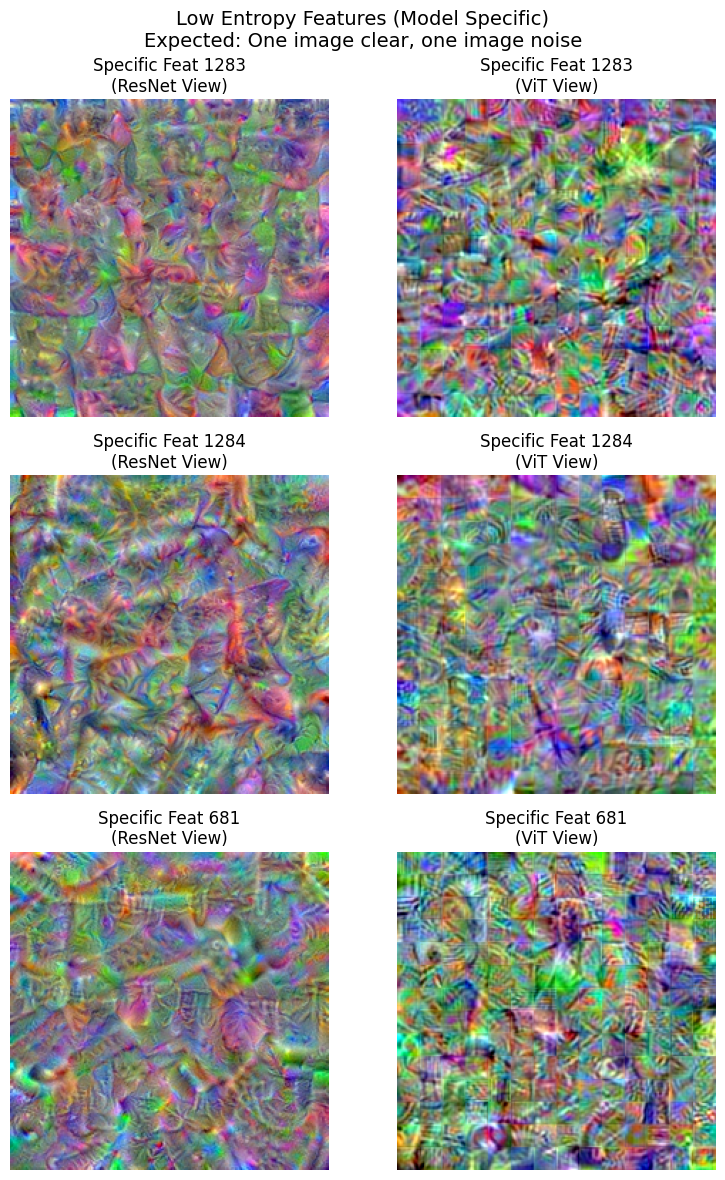

In [11]:
print(f"Visualizing Model-Specific Features: {specific_indices}")

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i, feat_idx in enumerate(specific_indices):
    print(f"Optimizing Specific Feature {feat_idx}...")
    
    # We use the same robust optimization function you defined earlier
    # 1. Optimize for ResNet
    img_resnet = optimize_feature_robust(model_a, usae.encoders[0], 0, feat_idx)
    
    # 2. Optimize for ViT
    img_vit = optimize_feature_robust(model_b, usae.encoders[1], 1, feat_idx)
    
    # Plot ResNet result
    axes[i, 0].imshow(img_resnet)
    axes[i, 0].set_title(f"Specific Feat {feat_idx}\n(ResNet View)")
    axes[i, 0].axis('off')
    
    # Plot ViT result
    axes[i, 1].imshow(img_vit)
    axes[i, 1].set_title(f"Specific Feat {feat_idx}\n(ViT View)")
    axes[i, 1].axis('off')

plt.suptitle("Low Entropy Features (Model Specific)\nExpected: One image clear, one image noise", fontsize=14)
plt.tight_layout()
plt.show()